In [1]:
import pandas as pd

from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark

In [2]:
df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-900*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

2021-09-30 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


In [3]:
data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=chosen_ticker, no_plotting=True)


Shape dataset (6409, 11)
means:  Close           8.036797e+01
Volume          1.087093e+06
MarketCap       1.954685e+10
Weight          6.289315e-03
Return          4.417263e-04
LogReturn       1.723115e-04
WeightedRet     4.306955e-06
SMA20           8.029539e+01
EMA20           8.029467e+01
RSI14           5.211280e+01
ReturnVola20    2.049862e-02
dtype: float64
stds:  Close           7.186329e+01
Volume          9.459844e+05
MarketCap       1.747837e+10
Weight          3.087590e-03
Return          2.315582e-02
LogReturn       2.325378e-02
WeightedRet     1.423583e-04
SMA20           7.175884e+01
EMA20           7.168856e+01
RSI14           1.325365e+01
ReturnVola20    1.071267e-02
dtype: float64


In [31]:
data_values = data_values
window_step_length = 5
window_size = 50
num_test_points = 900

horizon = 5 #3 is good
target_idx = 0

n_features = data_values.shape[1]

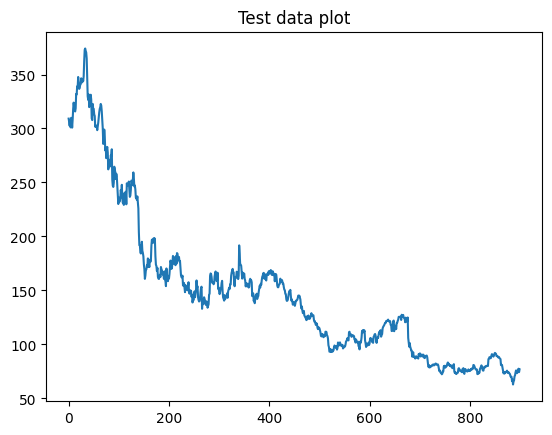

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.7012497597592897
Normalized Benchmark: 0.026758321859783527


In [97]:
train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )

In [5]:
from train.train_functions import get_device, plot_training, test_model_output
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionGRUV2 import CrossAttentionGRUV2

import deeplay as dl
import torch

In [6]:
device = get_device()
print(device)

cuda:0


In [7]:
cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
cross_attn_gru_v2 = CrossAttentionGRUV2(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)

In [9]:
gru_dl = dl.RecurrentModel(
    in_features=n_features,
    hidden_features=[128, 128, 128],
    out_features=1,
    rnn_type="GRU",
    dropout=0.2,
)

In [10]:
epochs = 40

In [52]:
chosen_model = cross_attn_gru_v1
print(type(chosen_model))

<class 'single_asset_models.CrossAttentionGRUV1.CrossAttentionGRUV1'>


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

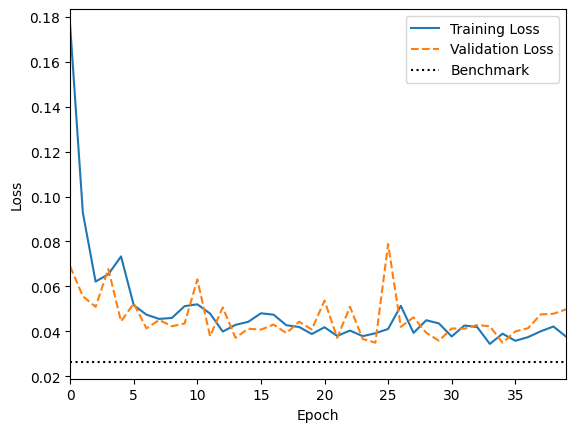

In [53]:
#trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)

chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
trainer.fit(chosen_model_reg, train_loader, val_loader)
train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
plot_training(epochs, train_losses, val_losses, benchmark)

In [54]:
test_model_output(model=chosen_model_reg, data_loader=val_loader, num_tests=10)

Last 10 timesteps (input) and true vs predicted temperature:
Sample 1: Last input temp = 0.35, True = -0.75, Pred = -0.75
Sample 2: Last input temp = -0.69, True = -0.92, Pred = -0.94
Sample 3: Last input temp = 0.27, True = -0.17, Pred = -0.15
Sample 4: Last input temp = -0.48, True = 0.65, Pred = 0.75
Sample 5: Last input temp = -0.67, True = -0.68, Pred = -0.71
Sample 6: Last input temp = 0.09, True = -0.68, Pred = -0.72
Sample 7: Last input temp = -0.09, True = -0.83, Pred = -0.86
Sample 8: Last input temp = -0.44, True = 1.05, Pred = 1.10
Sample 9: Last input temp = 0.87, True = -0.55, Pred = -0.55
Sample 10: Last input temp = -0.60, True = 0.94, Pred = 1.04


variance of returns for old data:  0.0015558192717572451
start window shape:  torch.Size([6, 11])
test data shape torch.Size([900, 11])


/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


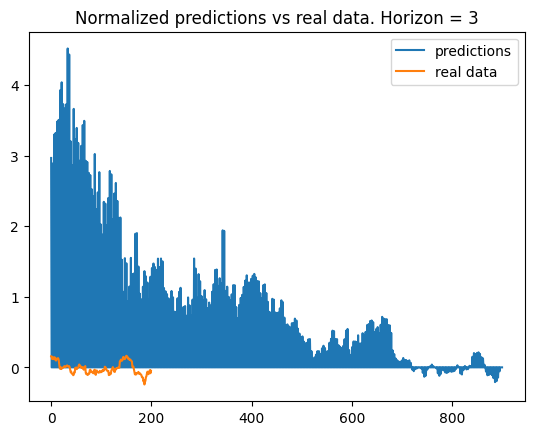

In [57]:
from model_inference.inference_functions import generate_predictions_and_returns, plot_pred_vs_real

predictions_normalized, test_weights, test_pnl = generate_predictions_and_returns(chosen_model_reg, window_step_length, data_values, target_idx, num_of_future_predictions=num_test_points, horizon=horizon)

plot_pred_vs_real(predictions_normalized, data_values, target_idx, horizon, minimal_plotting=True)

3
variance of returns for old data:  0.0015558192717572451
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(305.1500)
period from idx:  0  to idx  3
prediction at 3:  tensor(321.5646)
last price from test data:  305.1499938964844
real price 3 steps forward:  tensor(308.1000)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(302.5000)
period from idx:  3  to idx  6
prediction at 3:  tensor(312.5987)
last price from test data:  tensor(302.5000)
real price 3 steps forward:  tensor(308.2000)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(309.9000)
period from idx:  6  to idx  9
prediction at 3:  tensor(325.7504)
last price from test data:  tensor(309.9000)
real price 3 steps forward:  tensor(318.0500)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:

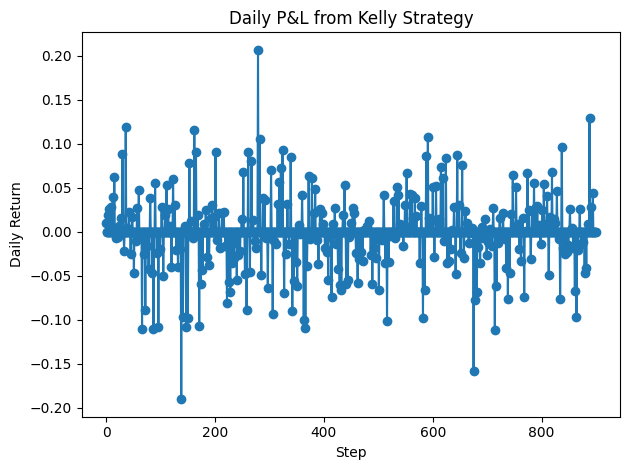

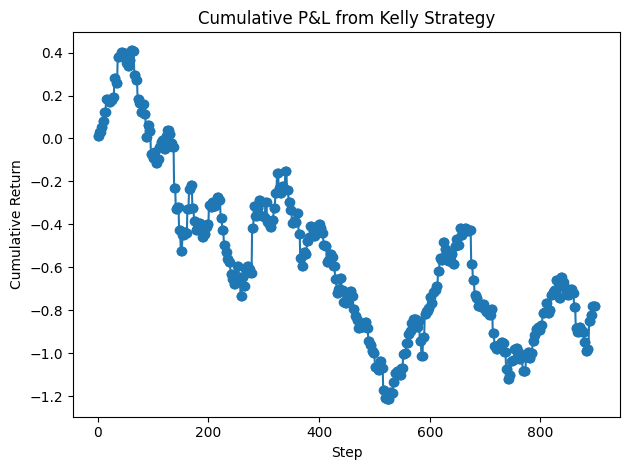

In [58]:
from model_inference.inference_functions import  generate_predictions_and_returns, plot_realized_returns
import matplotlib.pyplot as plt
import numpy as np

print(horizon)
preds_norm, weights, pnl = generate_predictions_and_returns(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  print_values_for_allocation=True)

plot_realized_returns(pnl, plot_only_cumulative=False)

In [59]:
print(weights)
print()
print(pnl)

'''Model version_61 had 0.02 in mae'''

[ 1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
 -1.          0.          0.         -1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.         

'Model version_61 had 0.02 in mae'

Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


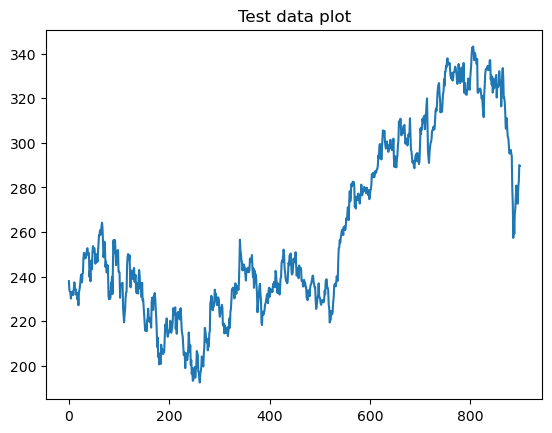

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.034221040994622
Normalized Benchmark: 0.032014451694686315


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

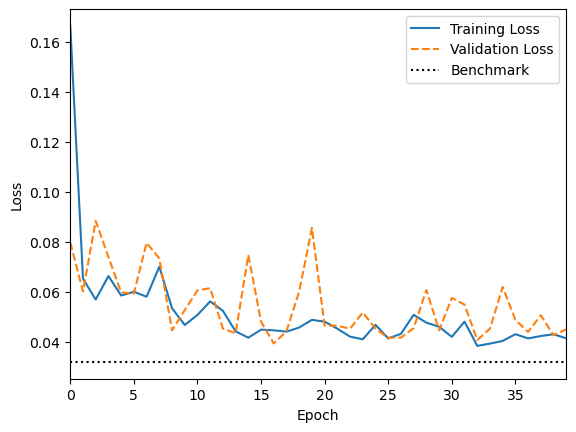

variance of returns for old data:  0.001768591526903312
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(237.3664)
period from idx:  0  to idx  5
prediction at 5:  tensor(236.5962)
last price from test data:  237.36639404296875
real price 5 steps forward:  tensor(233.1776)
kelly weight:  {tensor(-1.8346)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(230.1989)
period from idx:  5  to idx  10
prediction at 5:  tensor(227.7011)
last price from test data:  tensor(230.1989)
real price 5 steps forward:  tensor(235.1324)
kelly weight:  {tensor(-6.1351)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(231.9675)
period from idx:  10  to idx  15
prediction at 5:  tensor(231.4529)
last price from test data:  tensor(231.9675)
real price 5 steps forward:  tensor(231.7813)
kelly weight:  {tensor(-1.2542)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(235.8990)
period from idx:  105  to idx  110
prediction at 5:  tensor(233.8503)
last price from test data:  tensor(235.8989)
real price 5 steps forward:  tensor(219.5848)
kelly weight:  {tensor(-4.9104)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(222.5851)
period from idx:  110  to idx  115
prediction at 5:  tensor(223.0873)
last price from test data:  tensor(222.5851)
real price 5 steps forward:  tensor(233.1799)
kelly weight:  {tensor(1.2757)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(232.8987)
period from idx:  115  to idx  120
prediction at 5:  tensor(236.2877)
last price from test data:  tensor(232.8986)
real price 5 steps forward:  tensor(247.7126)
kelly weight:  {tensor(8.2279)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(248.0877)
period from idx:  120  to idx  125
prediction at 5:  tensor(251.5981)
last price from test data:  tensor(248.0877)

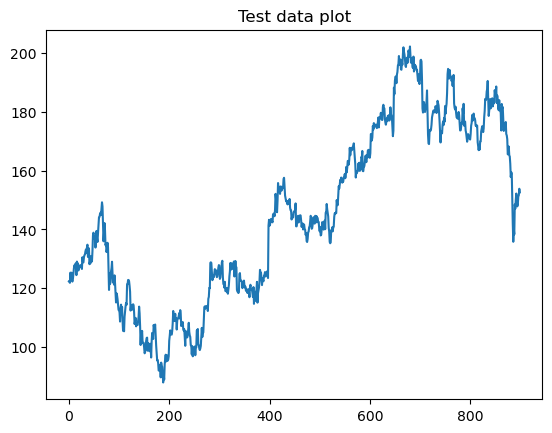

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.774219403389928
Normalized Benchmark: 0.028600962169461095


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

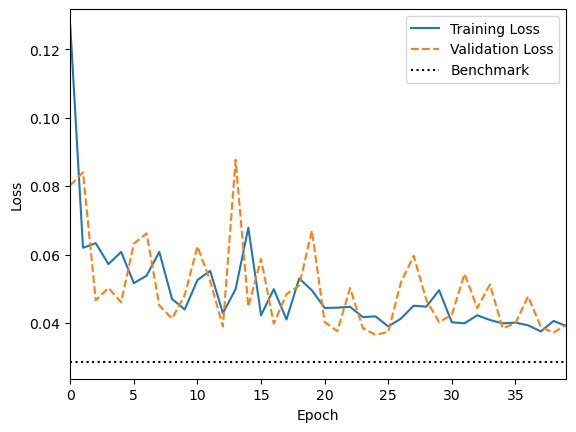

variance of returns for old data:  0.0019968258675057545
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(121.7129)
period from idx:  0  to idx  5
prediction at 5:  tensor(126.6234)
last price from test data:  121.7128677368164
real price 5 steps forward:  tensor(125.2994)
kelly weight:  {tensor(20.2045)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(123.2762)
period from idx:  5  to idx  10
prediction at 5:  tensor(126.3147)
last price from test data:  tensor(123.2762)
real price 5 steps forward:  tensor(126.7708)
kelly weight:  {tensor(12.3433)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(124.8856)
period from idx:  10  to idx  15
prediction at 5:  tensor(126.3163)
last price from test data:  tensor(124.8856)
real price 5 steps forward:  tensor(124.4718)
kelly weight:  {tensor(5.7375)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  t

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


tensor(112.6322)
real price 5 steps forward:  tensor(110.9656)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(114.4376)
period from idx:  105  to idx  110
prediction at 5:  tensor(123.1303)
last price from test data:  tensor(114.4376)
real price 5 steps forward:  tensor(105.3872)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(108.6046)
period from idx:  110  to idx  115
prediction at 5:  tensor(119.2889)
last price from test data:  tensor(108.6046)
real price 5 steps forward:  tensor(114.3913)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(114.9931)
period from idx:  115  to idx  120
prediction at 5:  tensor(119.0547)
last price from test data:  tensor(114.9931)
real price 5 steps forward:  tensor(122.4001)
kelly weight:  {tensor(17.6883)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.8167)
period from idx:  120  to 

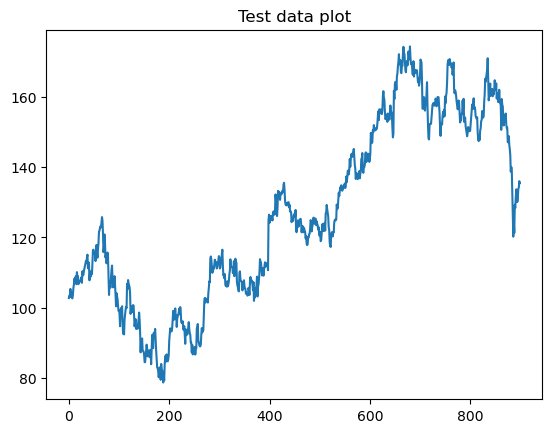

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.6857419509094121
Normalized Benchmark: 0.028122475445122582


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

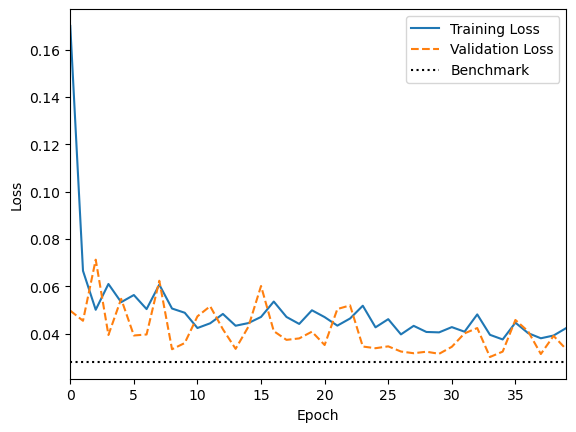

variance of returns for old data:  0.002136970689422765
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(102.7746)
period from idx:  0  to idx  5
prediction at 5:  tensor(105.1105)
last price from test data:  102.77459716796876
real price 5 steps forward:  tensor(104.4463)
kelly weight:  {tensor(10.6360)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(103.0494)
period from idx:  5  to idx  10
prediction at 5:  tensor(104.6545)
last price from test data:  tensor(103.0494)
real price 5 steps forward:  tensor(106.5531)
kelly weight:  {tensor(7.2890)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(105.6142)
period from idx:  10  to idx  15
prediction at 5:  tensor(104.9962)
last price from test data:  tensor(105.6142)
real price 5 steps forward:  tensor(106.6447)
kelly weight:  {tensor(-2.7379)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  t

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


tensor(102.7372)
last price from test data:  tensor(100.1474)
real price 5 steps forward:  tensor(106.3792)
kelly weight:  {tensor(12.1009)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(106.9101)
period from idx:  120  to idx  125
prediction at 5:  tensor(109.2805)
last price from test data:  tensor(106.9101)
real price 5 steps forward:  tensor(100.3090)
kelly weight:  {tensor(10.3752)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(99.5935)
period from idx:  125  to idx  130
prediction at 5:  tensor(103.4381)
last price from test data:  tensor(99.5935)
real price 5 steps forward:  tensor(97.8855)
kelly weight:  {tensor(18.0645)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.5398)
period from idx:  130  to idx  135
prediction at 5:  tensor(102.6287)
last price from test data:  tensor(100.5398)
real price 5 steps forward:  tensor(94.4003)
kelly weight:  {tensor(9.7226)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last

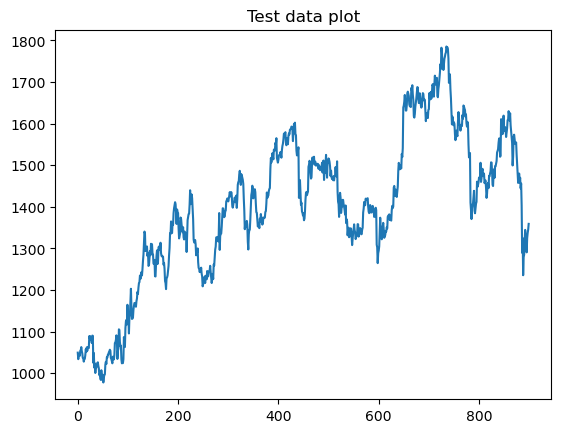

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 10.751978951831196
Normalized Benchmark: 0.05367490267147855


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

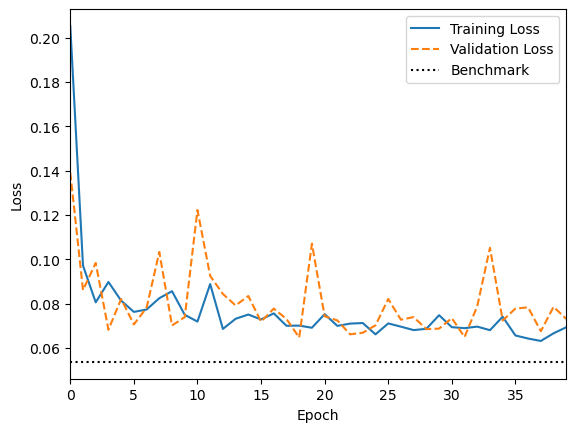

variance of returns for old data:  0.0012518121563095085
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1035.6300)
period from idx:  0  to idx  5
prediction at 5:  tensor(1015.9164)
last price from test data:  1035.6300048828125
real price 5 steps forward:  tensor(1053.9176)
kelly weight:  {tensor(-15.2063)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1041.5934)
period from idx:  5  to idx  10
prediction at 5:  tensor(1041.2863)
last price from test data:  tensor(1041.5934)
real price 5 steps forward:  tensor(1036.6239)
kelly weight:  {tensor(-0.2356)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1047.5565)
period from idx:  10  to idx  15
prediction at 5:  tensor(1061.2177)
last price from test data:  tensor(1047.5565)
real price 5 steps forward:  tensor(1042.9849)
kelly weight:  {tensor(10.4177)}
 
x_in shape:  torch.Size([1, 50, 11])
windows 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1195.3794)
period from idx:  120  to idx  125
prediction at 5:  tensor(1171.7883)
last price from test data:  tensor(1195.3794)
real price 5 steps forward:  tensor(1226.6273)
kelly weight:  {tensor(-15.7653)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1234.7875)
period from idx:  125  to idx  130
prediction at 5:  tensor(1203.3833)
last price from test data:  tensor(1234.7875)
real price 5 steps forward:  tensor(1269.8169)
kelly weight:  {tensor(-20.3168)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1249.9138)
period from idx:  130  to idx  135
prediction at 5:  tensor(1239.2802)
last price from test data:  tensor(1249.9138)
real price 5 steps forward:  tensor(1293.7007)
kelly weight:  {tensor(-6.7962)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1335.4971)
period from idx:  135  to idx  140
prediction at 5:  tensor(1297.7319)
last price from test data:

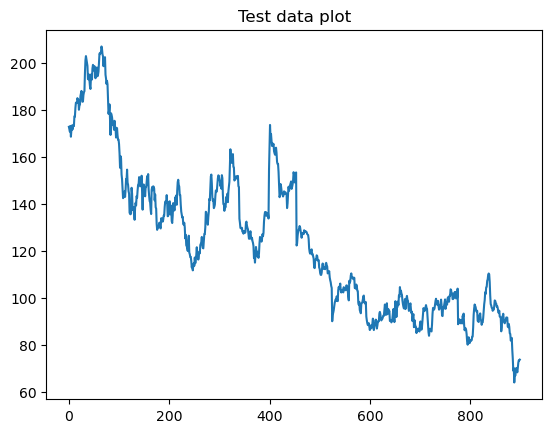

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.4817825600851413
Normalized Benchmark: 0.04924139623042702


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

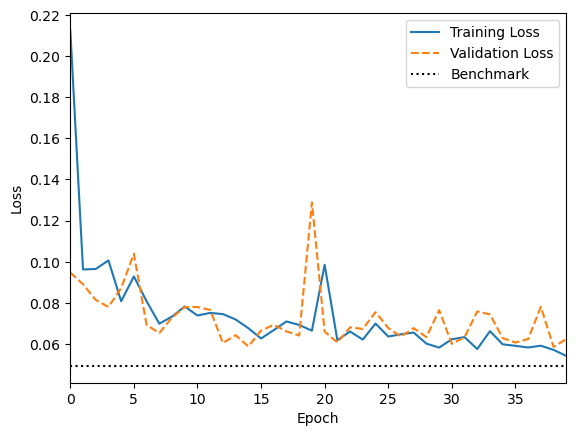

variance of returns for old data:  0.002355264336006256
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(177.4230)
period from idx:  0  to idx  5
prediction at 5:  tensor(168.4121)
last price from test data:  177.4230194091797
real price 5 steps forward:  tensor(171.5957)
kelly weight:  {tensor(-21.5635)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(168.6828)
period from idx:  5  to idx  10
prediction at 5:  tensor(164.6363)
last price from test data:  tensor(168.6828)
real price 5 steps forward:  tensor(173.2295)
kelly weight:  {tensor(-10.1854)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.7896)
period from idx:  10  to idx  15
prediction at 5:  tensor(166.9405)
last price from test data:  tensor(173.7896)
real price 5 steps forward:  tensor(183.0789)
kelly weight:  {tensor(-16.7330)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(167.4878)
period from idx:  100  to idx  105
prediction at 5:  tensor(166.6915)
last price from test data:  tensor(167.4878)
real price 5 steps forward:  tensor(152.5969)
kelly weight:  {tensor(-2.0186)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(159.4122)
period from idx:  105  to idx  110
prediction at 5:  tensor(161.6137)
last price from test data:  tensor(159.4122)
real price 5 steps forward:  tensor(143.6344)
kelly weight:  {tensor(5.8637)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(143.0275)
period from idx:  110  to idx  115
prediction at 5:  tensor(146.9991)
last price from test data:  tensor(143.0275)
real price 5 steps forward:  tensor(150.3096)
kelly weight:  {tensor(11.7899)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(150.5897)
period from idx:  115  to idx  120
prediction at 5:  tensor(148.7400)
last price from test data:  tensor(150.5897

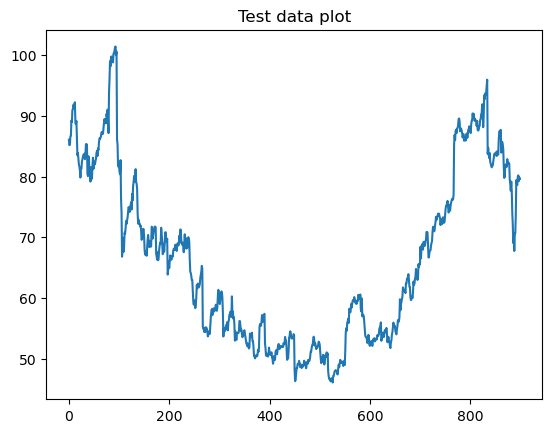

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 3.204886106904163
Normalized Benchmark: 0.05091414409349156


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

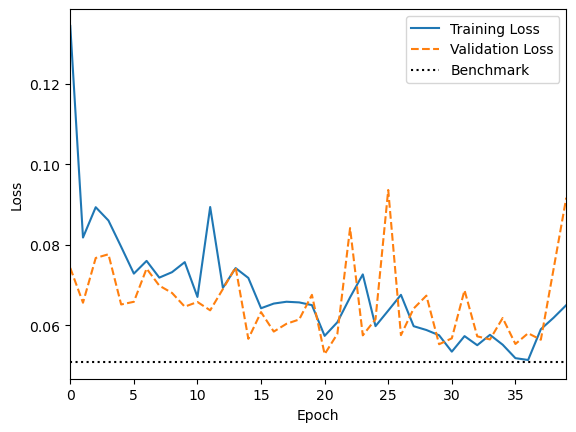

variance of returns for old data:  0.003744016300538617
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(85.1118)
period from idx:  0  to idx  5
prediction at 5:  tensor(81.7352)
last price from test data:  85.11177062988281
real price 5 steps forward:  tensor(89.2284)
kelly weight:  {tensor(-10.5962)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(86.7011)
period from idx:  5  to idx  10
prediction at 5:  tensor(83.6629)
last price from test data:  tensor(86.7011)
real price 5 steps forward:  tensor(91.6081)
kelly weight:  {tensor(-9.3595)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(91.8339)
period from idx:  10  to idx  15
prediction at 5:  tensor(88.5423)
last price from test data:  tensor(91.8339)
real price 5 steps forward:  tensor(89.1589)
kelly weight:  {tensor(-9.5733)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(88.6

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(81.5944)
period from idx:  100  to idx  105
prediction at 5:  tensor(81.4878)
last price from test data:  tensor(81.5944)
real price 5 steps forward:  tensor(73.9865)
kelly weight:  {tensor(-0.3489)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(76.3400)
period from idx:  105  to idx  110
prediction at 5:  tensor(75.6002)
last price from test data:  tensor(76.3400)
real price 5 steps forward:  tensor(68.4281)
kelly weight:  {tensor(-2.5885)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(67.6031)
period from idx:  110  to idx  115
prediction at 5:  tensor(68.3241)
last price from test data:  tensor(67.6031)
real price 5 steps forward:  tensor(72.2060)
kelly weight:  {tensor(2.8487)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(72.7098)
period from idx:  115  to idx  120
prediction at 5:  tensor(70.4875)
last price from test data:  tensor(72.7098)
real price 5 

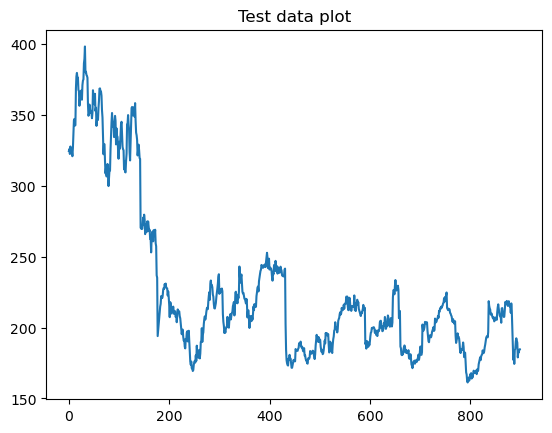

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.452274666969166
Normalized Benchmark: 0.047152437036083884


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

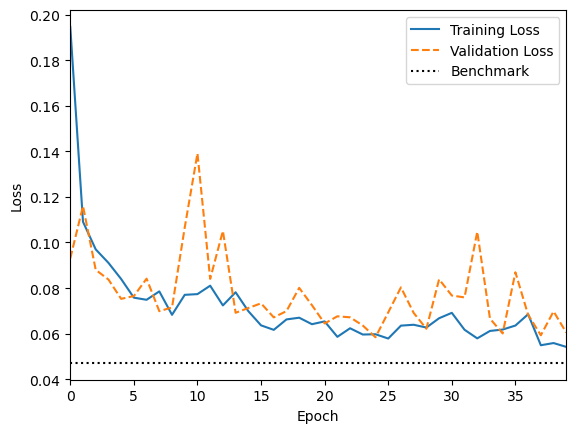

variance of returns for old data:  0.0017890656720501606
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(322.7426)
period from idx:  0  to idx  5
prediction at 5:  tensor(336.3950)
last price from test data:  322.7426147460937
real price 5 steps forward:  tensor(326.1750)
kelly weight:  {tensor(23.6442)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(323.3920)
period from idx:  5  to idx  10
prediction at 5:  tensor(325.9084)
last price from test data:  tensor(323.3920)
real price 5 steps forward:  tensor(346.1203)
kelly weight:  {tensor(4.3493)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(337.4928)
period from idx:  10  to idx  15
prediction at 5:  tensor(325.1509)
last price from test data:  tensor(337.4928)
real price 5 steps forward:  tensor(377.2906)
kelly weight:  {tensor(-20.4405)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(325.0618)
period from idx:  110  to idx  115
prediction at 5:  tensor(322.9576)
last price from test data:  tensor(325.0618)
real price 5 steps forward:  tensor(322.6498)
kelly weight:  {tensor(-3.6182)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(317.7331)
period from idx:  115  to idx  120
prediction at 5:  tensor(313.0377)
last price from test data:  tensor(317.7331)
real price 5 steps forward:  tensor(339.6265)
kelly weight:  {tensor(-8.2601)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(343.3373)
period from idx:  120  to idx  125
prediction at 5:  tensor(343.5541)
last price from test data:  tensor(343.3373)
real price 5 steps forward:  tensor(354.9334)
kelly weight:  {tensor(0.3530)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(342.7806)
period from idx:  125  to idx  130
prediction at 5:  tensor(339.6497)
last price from test data:  tensor(342.7806

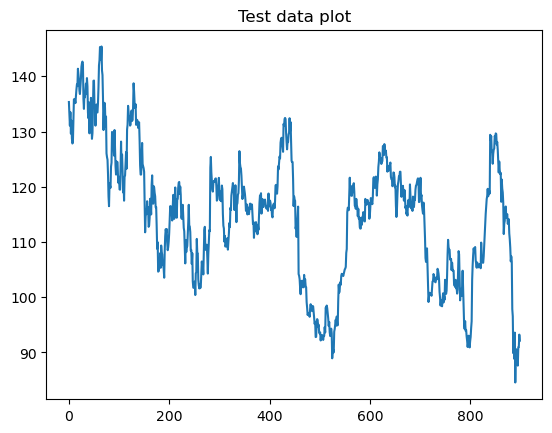

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.8191733522080752
Normalized Benchmark: 0.02824805761666127


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

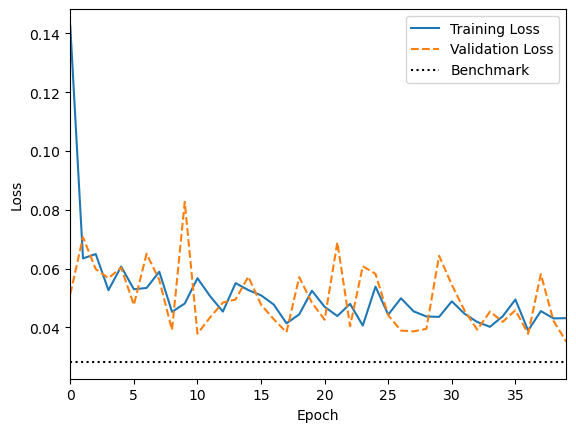

variance of returns for old data:  0.0024359990626876995
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(134.4504)
period from idx:  0  to idx  5
prediction at 5:  tensor(145.6582)
last price from test data:  134.45040893554688
real price 5 steps forward:  tensor(131.9615)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(129.6219)
period from idx:  5  to idx  10
prediction at 5:  tensor(134.9722)
last price from test data:  tensor(129.6219)
real price 5 steps forward:  tensor(135.8442)
kelly weight:  {tensor(16.9441)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(132.2602)
period from idx:  10  to idx  15
prediction at 5:  tensor(135.1335)
last price from test data:  tensor(132.2602)
real price 5 steps forward:  tensor(137.5864)
kelly weight:  {tensor(8.9181)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tens

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(120.9606)
period from idx:  110  to idx  115
prediction at 5:  tensor(126.8293)
last price from test data:  tensor(120.9606)
real price 5 steps forward:  tensor(123.2504)
kelly weight:  {tensor(19.9170)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(126.2868)
period from idx:  115  to idx  120
prediction at 5:  tensor(127.6455)
last price from test data:  tensor(126.2868)
real price 5 steps forward:  tensor(132.4095)
kelly weight:  {tensor(4.4167)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(133.5046)
period from idx:  120  to idx  125
prediction at 5:  tensor(136.0774)
last price from test data:  tensor(133.5046)
real price 5 steps forward:  tensor(133.8033)
kelly weight:  {tensor(7.9109)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(132.8575)
period from idx:  125  to idx  130
prediction at 5:  tensor(133.7280)
last price from test data:  tensor(132.8575)

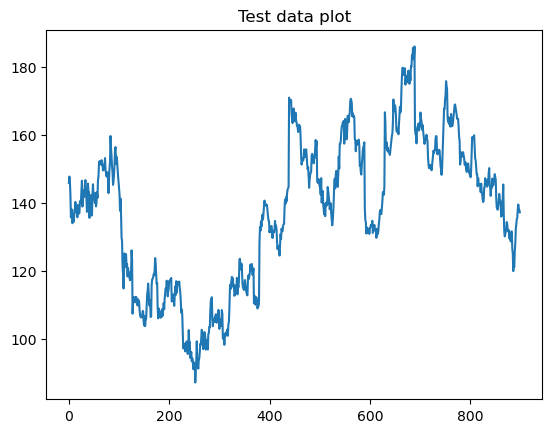

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.9761554924554603
Normalized Benchmark: 0.054579784747538794


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

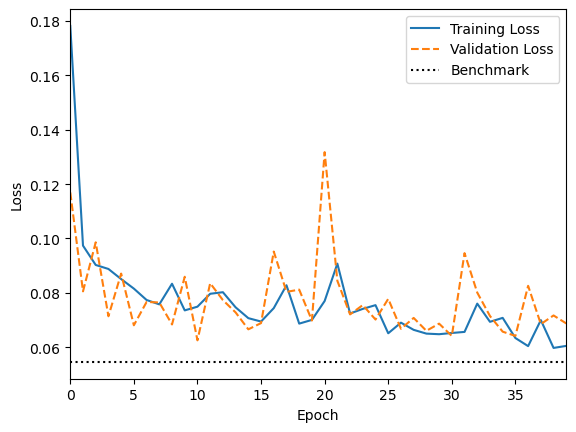

variance of returns for old data:  0.0018075184414597936
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(150.9875)
period from idx:  0  to idx  5
prediction at 5:  tensor(141.5031)
last price from test data:  150.98751831054688
real price 5 steps forward:  tensor(138.1532)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.7007)
period from idx:  5  to idx  10
prediction at 5:  tensor(136.3227)
last price from test data:  tensor(135.7007)
real price 5 steps forward:  tensor(134.4255)
kelly weight:  {tensor(2.5355)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(136.6327)
period from idx:  10  to idx  15
prediction at 5:  tensor(136.5074)
last price from test data:  tensor(136.6327)
real price 5 steps forward:  tensor(138.0224)
kelly weight:  {tensor(-0.5073)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  ten

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(136.4730)
period from idx:  105  to idx  110
prediction at 5:  tensor(138.7142)
last price from test data:  tensor(136.4730)
real price 5 steps forward:  tensor(119.5308)
kelly weight:  {tensor(9.0854)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(114.7339)
period from idx:  110  to idx  115
prediction at 5:  tensor(120.6561)
last price from test data:  tensor(114.7339)
real price 5 steps forward:  tensor(120.8746)
kelly weight:  {tensor(28.5567)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(124.8040)
period from idx:  115  to idx  120
prediction at 5:  tensor(125.5037)
last price from test data:  tensor(124.8040)
real price 5 steps forward:  tensor(118.8504)
kelly weight:  {tensor(3.1017)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(118.5102)
period from idx:  120  to idx  125
prediction at 5:  tensor(120.1489)
last price from test data:  tensor(118.5102)

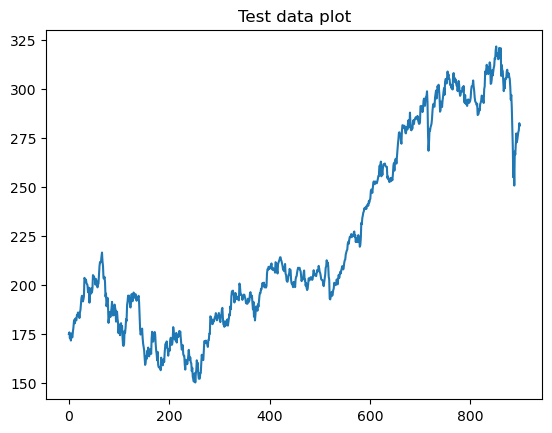

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.9798422953070595
Normalized Benchmark: 0.025144869512186013


INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

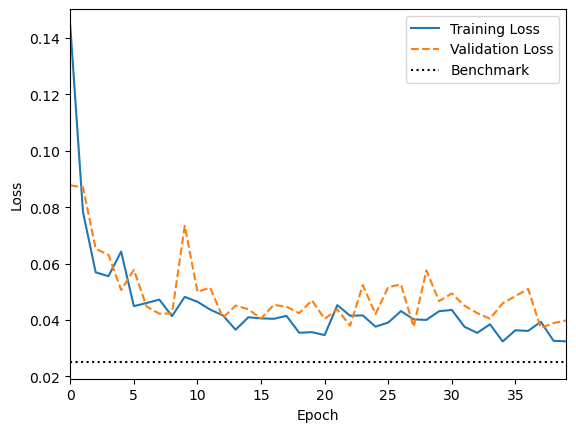

variance of returns for old data:  0.0012701513129329094
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(174.8412)
period from idx:  0  to idx  5
prediction at 5:  tensor(181.1769)
last price from test data:  174.84124755859375
real price 5 steps forward:  tensor(175.2484)
kelly weight:  {tensor(28.5295)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(171.6579)
period from idx:  5  to idx  10
prediction at 5:  tensor(177.3813)
last price from test data:  tensor(171.6579)
real price 5 steps forward:  tensor(181.2263)
kelly weight:  {tensor(26.2501)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(178.1911)
period from idx:  10  to idx  15
prediction at 5:  tensor(180.3327)
last price from test data:  tensor(178.1911)
real price 5 steps forward:  tensor(181.9666)
kelly weight:  {tensor(9.4623)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(175.4037)
period from idx:  100  to idx  105
prediction at 5:  tensor(188.6000)
last price from test data:  tensor(175.4037)
real price 5 steps forward:  tensor(176.5753)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(180.4806)
period from idx:  105  to idx  110
prediction at 5:  tensor(189.2034)
last price from test data:  tensor(180.4806)
real price 5 steps forward:  tensor(169.7875)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(168.9320)
period from idx:  110  to idx  115
prediction at 5:  tensor(180.7395)
last price from test data:  tensor(168.9320)
real price 5 steps forward:  tensor(181.5592)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(182.5076)
period from idx:  115  to idx  120
prediction at 5:  tensor(188.4344)
last price from test data:  tensor(182.5076)
real pric

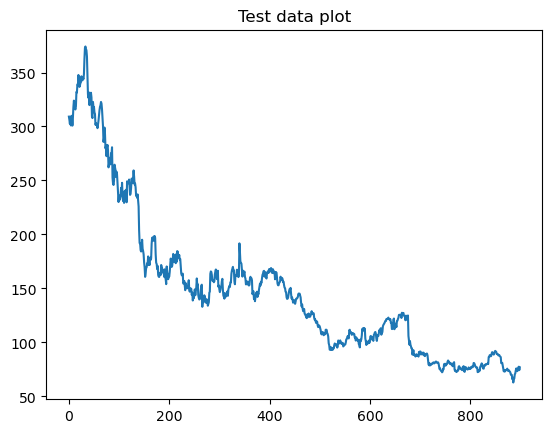

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.2436648869757048
Normalized Benchmark: 0.035505513552032304


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

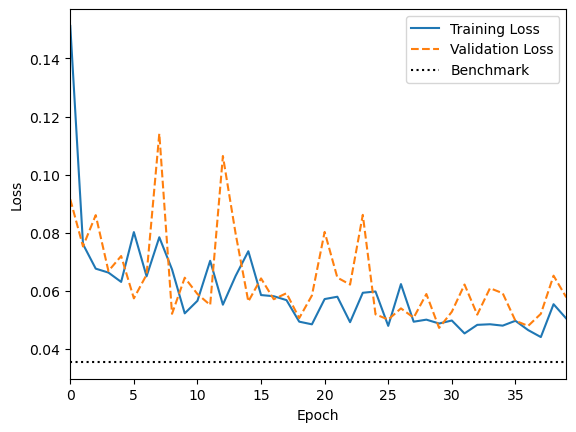

variance of returns for old data:  0.002659434511034774
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(305.1500)
period from idx:  0  to idx  5
prediction at 5:  tensor(324.0298)
last price from test data:  305.1499938964844
real price 5 steps forward:  tensor(309.9000)
kelly weight:  {tensor(23.2646)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(301.)
period from idx:  5  to idx  10
prediction at 5:  tensor(315.8576)
last price from test data:  tensor(301.)
real price 5 steps forward:  tensor(323.9500)
kelly weight:  {tensor(18.5606)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(318.0500)
period from idx:  10  to idx  15
prediction at 5:  tensor(341.9414)
last price from test data:  tensor(318.0500)
real price 5 steps forward:  tensor(331.9500)
kelly weight:  {tensor(28.2460)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(31

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(243.1000)
period from idx:  105  to idx  110
prediction at 5:  tensor(274.4382)
last price from test data:  tensor(243.1000)
real price 5 steps forward:  tensor(229.2500)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(232.3500)
period from idx:  110  to idx  115
prediction at 5:  tensor(254.5998)
last price from test data:  tensor(232.3500)
real price 5 steps forward:  tensor(229.8000)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(241.4500)
period from idx:  115  to idx  120
prediction at 5:  tensor(270.7416)
last price from test data:  tensor(241.4500)
real price 5 steps forward:  tensor(250.8500)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(247.9000)
period from idx:  120  to idx  125
prediction at 5:  tensor(279.2332)
last price from test data:  tensor(247.9000)
real pric

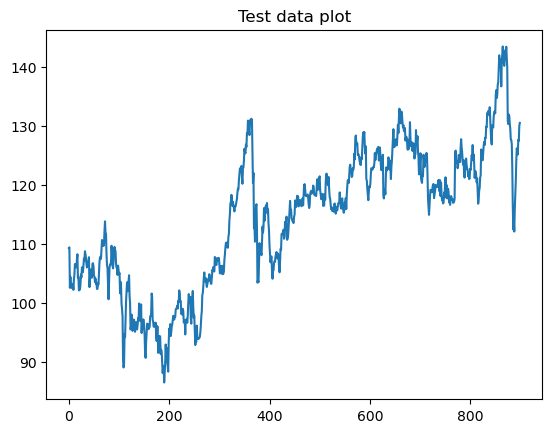

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.717959153444268
Normalized Benchmark: 0.08228778144413815


INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

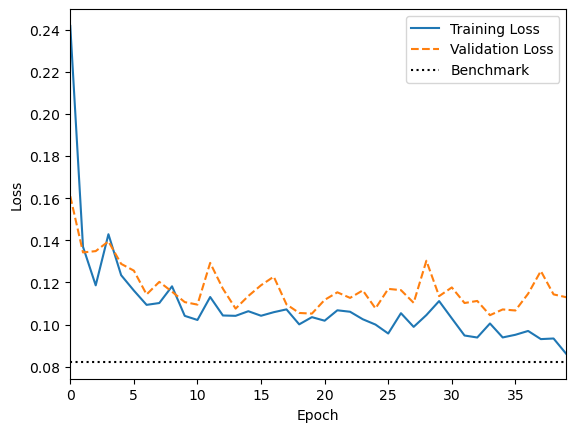

variance of returns for old data:  0.0018121491394682322
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(109.5793)
period from idx:  0  to idx  5
prediction at 5:  tensor(110.2643)
last price from test data:  109.57929229736328
real price 5 steps forward:  tensor(103.2580)
kelly weight:  {tensor(3.4498)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(102.6549)
period from idx:  5  to idx  10
prediction at 5:  tensor(103.0892)
last price from test data:  tensor(102.6549)
real price 5 steps forward:  tensor(104.0361)
kelly weight:  {tensor(2.3348)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(102.2270)
period from idx:  10  to idx  15
prediction at 5:  tensor(103.7575)
last price from test data:  tensor(102.2270)
real price 5 steps forward:  tensor(106.0203)
kelly weight:  {tensor(8.2620)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  te

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.3205)
period from idx:  115  to idx  120
prediction at 5:  tensor(97.9623)
last price from test data:  tensor(100.3205)
real price 5 steps forward:  tensor(104.6975)
kelly weight:  {tensor(-12.9720)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(103.7054)
period from idx:  120  to idx  125
prediction at 5:  tensor(102.6089)
last price from test data:  tensor(103.7054)
real price 5 steps forward:  tensor(98.0413)
kelly weight:  {tensor(-5.8347)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(96.2003)
period from idx:  125  to idx  130
prediction at 5:  tensor(96.1651)
last price from test data:  tensor(96.2003)
real price 5 steps forward:  tensor(97.1697)
kelly weight:  {tensor(-0.2016)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(96.9641)
period from idx:  130  to idx  135
prediction at 5:  tensor(97.6306)
last price from test data:  tensor(96.9641)
real 

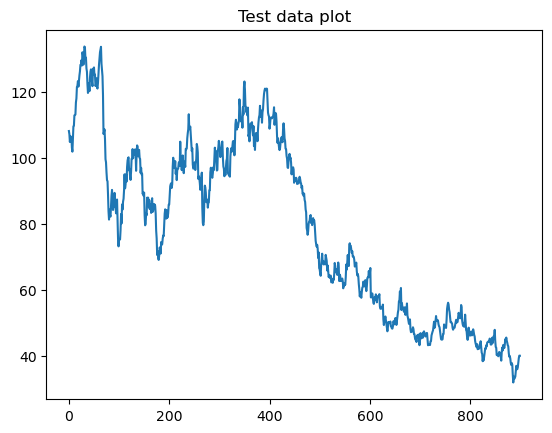

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.3798780934939291
Normalized Benchmark: 0.022614515202351276


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

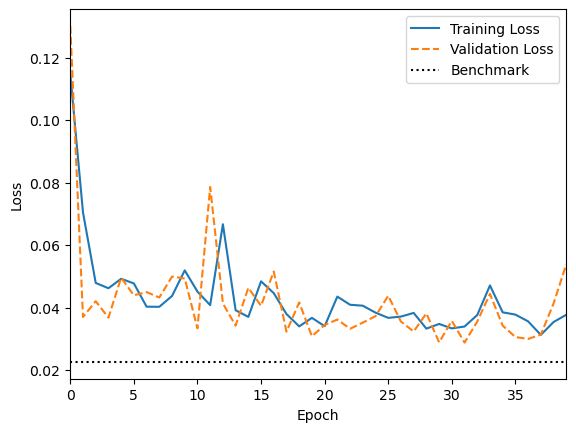

variance of returns for old data:  0.0019275791868775107
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(108.9700)
period from idx:  0  to idx  5
prediction at 5:  tensor(102.8582)
last price from test data:  108.97003936767578
real price 5 steps forward:  tensor(106.4268)
kelly weight:  {tensor(-29.0973)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(105.0084)
period from idx:  5  to idx  10
prediction at 5:  tensor(100.8296)
last price from test data:  tensor(105.0084)
real price 5 steps forward:  tensor(109.8015)
kelly weight:  {tensor(-20.6450)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(109.6548)
period from idx:  10  to idx  15
prediction at 5:  tensor(105.4355)
last price from test data:  tensor(109.6548)
real price 5 steps forward:  tensor(118.1161)
kelly weight:  {tensor(-19.9616)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last pric

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.0798)
period from idx:  115  to idx  120
prediction at 5:  tensor(86.3613)
last price from test data:  tensor(95.0798)
real price 5 steps forward:  tensor(96.2927)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.2642)
period from idx:  120  to idx  125
prediction at 5:  tensor(91.3762)
last price from test data:  tensor(100.2642)
real price 5 steps forward:  tensor(99.7751)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.9797)
period from idx:  125  to idx  130
prediction at 5:  tensor(89.0478)
last price from test data:  tensor(95.9797)
real price 5 steps forward:  tensor(102.3184)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(101.8488)
period from idx:  130  to idx  135
prediction at 5:  tensor(95.4016)
last price from test data:  tensor(101.8488)
real price 5 ste

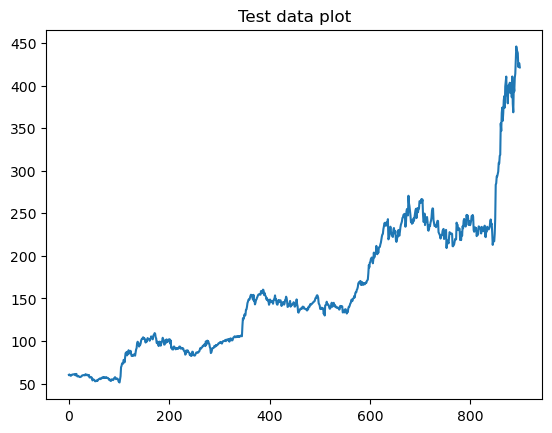

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.0500316354770993
Normalized Benchmark: 0.044638347137164865


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

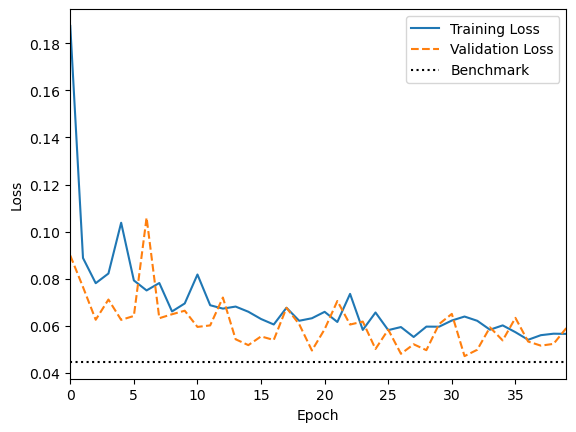

variance of returns for old data:  0.0020137767109126717
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.6015)
period from idx:  0  to idx  5
prediction at 5:  tensor(59.7182)
last price from test data:  60.60148620605469
real price 5 steps forward:  tensor(60.1173)
kelly weight:  {tensor(-7.2377)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(59.1246)
period from idx:  5  to idx  10
prediction at 5:  tensor(58.8045)
last price from test data:  tensor(59.1246)
real price 5 steps forward:  tensor(60.8436)
kelly weight:  {tensor(-2.6885)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.7468)
period from idx:  10  to idx  15
prediction at 5:  tensor(60.1735)
last price from test data:  tensor(60.7468)
real price 5 steps forward:  tensor(61.3520)
kelly weight:  {tensor(-4.6865)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(61.0

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(77.6222)
period from idx:  110  to idx  115
prediction at 5:  tensor(70.6001)
last price from test data:  tensor(77.6222)
real price 5 steps forward:  tensor(87.1858)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(85.2972)
period from idx:  115  to idx  120
prediction at 5:  tensor(70.4127)
last price from test data:  tensor(85.2972)
real price 5 steps forward:  tensor(86.8468)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(89.1711)
period from idx:  120  to idx  125
prediction at 5:  tensor(71.9996)
last price from test data:  tensor(89.1711)
real price 5 steps forward:  tensor(82.5129)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(85.1036)
period from idx:  125  to idx  130
prediction at 5:  tensor(70.0689)
last price from test data:  tensor(85.1036)
real price 5 steps fo

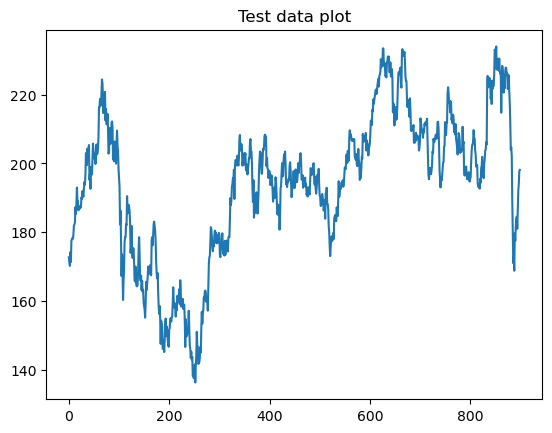

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.13645448726277
Normalized Benchmark: 0.04937367913458894


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

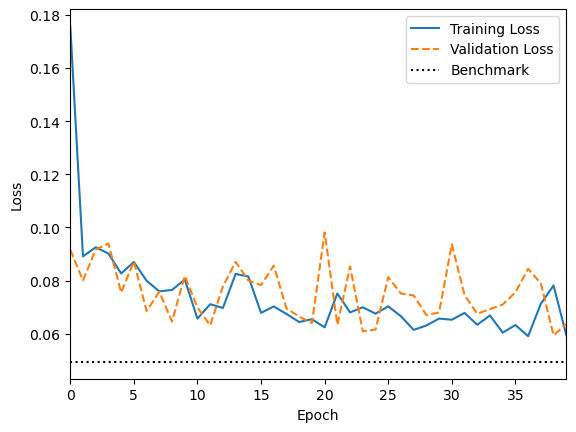

variance of returns for old data:  0.0019666394748429233
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(171.9328)
period from idx:  0  to idx  5
prediction at 5:  tensor(177.7502)
last price from test data:  171.9327850341797
real price 5 steps forward:  tensor(177.5122)
kelly weight:  {tensor(17.2048)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(171.3319)
period from idx:  5  to idx  10
prediction at 5:  tensor(175.4514)
last price from test data:  tensor(171.3319)
real price 5 steps forward:  tensor(181.8900)
kelly weight:  {tensor(12.2260)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(179.3148)
period from idx:  10  to idx  15
prediction at 5:  tensor(179.4927)
last price from test data:  tensor(179.3148)
real price 5 steps forward:  tensor(188.4136)
kelly weight:  {tensor(0.5044)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  t

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(198.2849)
period from idx:  100  to idx  105
prediction at 5:  tensor(202.7477)
last price from test data:  tensor(198.2849)
real price 5 steps forward:  tensor(167.2546)
kelly weight:  {tensor(11.4442)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(177.5981)
period from idx:  105  to idx  110
prediction at 5:  tensor(194.3902)
last price from test data:  tensor(177.5981)
real price 5 steps forward:  tensor(168.9285)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(166.0958)
period from idx:  110  to idx  115
prediction at 5:  tensor(182.7865)
last price from test data:  tensor(166.0958)
real price 5 steps forward:  tensor(182.0616)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(182.3191)
period from idx:  115  to idx  120
prediction at 5:  tensor(183.0704)
last price from test data:  tensor(182.3191)
real 

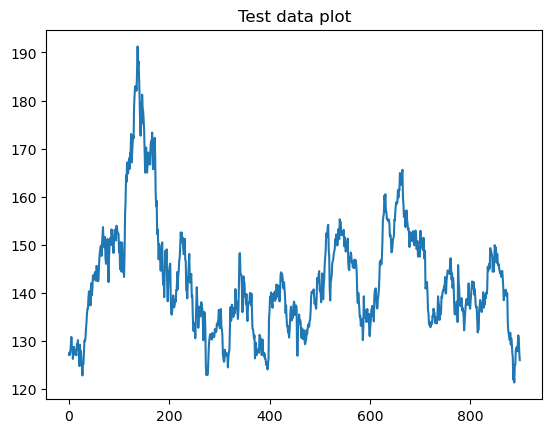

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 0.725257158116979
Normalized Benchmark: 0.019438972142527728


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

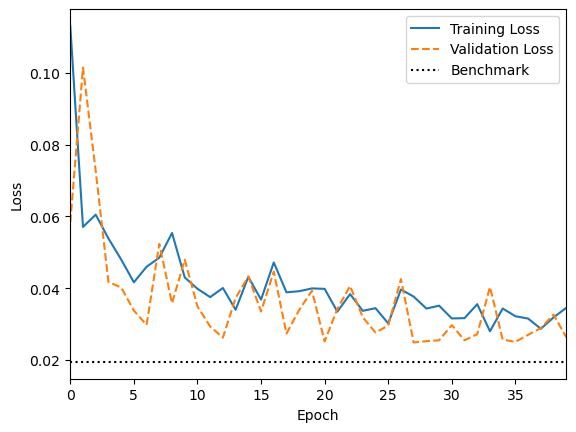

variance of returns for old data:  0.0017711429483916676
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(126.4020)
period from idx:  0  to idx  5
prediction at 5:  tensor(128.1634)
last price from test data:  126.4019546508789
real price 5 steps forward:  tensor(130.7799)
kelly weight:  {tensor(7.8681)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(129.2430)
period from idx:  5  to idx  10
prediction at 5:  tensor(131.7198)
last price from test data:  tensor(129.2430)
real price 5 steps forward:  tensor(128.7307)
kelly weight:  {tensor(10.8202)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(127.7060)
period from idx:  10  to idx  15
prediction at 5:  tensor(131.4156)
last price from test data:  tensor(127.7060)
real price 5 steps forward:  tensor(126.9608)
kelly weight:  {tensor(16.4005)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  t

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(144.8453)
period from idx:  105  to idx  110
prediction at 5:  tensor(146.7756)
last price from test data:  tensor(144.8453)
real price 5 steps forward:  tensor(143.2617)
kelly weight:  {tensor(7.5244)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(144.7987)
period from idx:  110  to idx  115
prediction at 5:  tensor(147.6091)
last price from test data:  tensor(144.7987)
real price 5 steps forward:  tensor(163.0557)
kelly weight:  {tensor(10.9586)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(164.4064)
period from idx:  115  to idx  120
prediction at 5:  tensor(158.1990)
last price from test data:  tensor(164.4064)
real price 5 steps forward:  tensor(167.9460)
kelly weight:  {tensor(-21.3176)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(166.1762)
period from idx:  120  to idx  125
prediction at 5:  tensor(161.6260)
last price from test data:  tensor(166.176

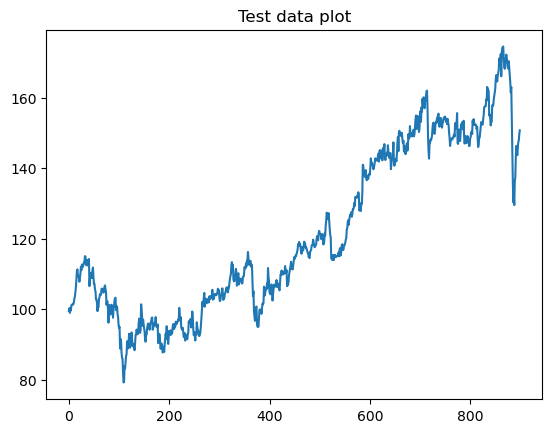

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.1333217565403428
Normalized Benchmark: 0.05657122919042016


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

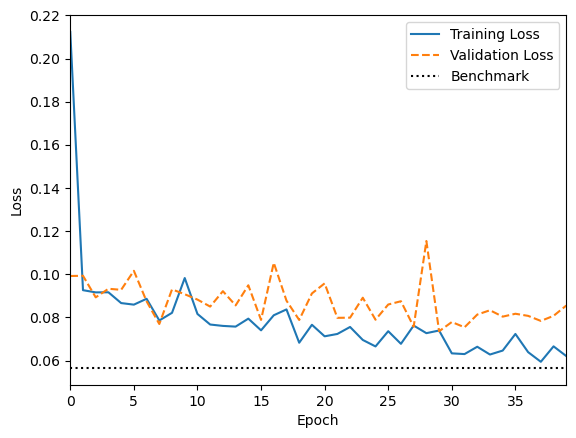

variance of returns for old data:  0.0024154906284550195
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(99.4988)
period from idx:  0  to idx  5
prediction at 5:  tensor(99.7679)
last price from test data:  99.4988250732422
real price 5 steps forward:  tensor(101.1451)
kelly weight:  {tensor(1.1195)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(99.6594)
period from idx:  5  to idx  10
prediction at 5:  tensor(99.4633)
last price from test data:  tensor(99.6594)
real price 5 steps forward:  tensor(101.9481)
kelly weight:  {tensor(-0.8145)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(101.4262)
period from idx:  10  to idx  15
prediction at 5:  tensor(101.5833)
last price from test data:  tensor(101.4262)
real price 5 steps forward:  tensor(108.5734)
kelly weight:  {tensor(0.6415)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


tensor(90.7280)
real price 5 steps forward:  tensor(79.4470)
kelly weight:  {tensor(3.3598)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(79.2154)
period from idx:  110  to idx  115
prediction at 5:  tensor(86.9576)
last price from test data:  tensor(79.2154)
real price 5 steps forward:  tensor(87.1717)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(86.7581)
period from idx:  115  to idx  120
prediction at 5:  tensor(87.7500)
last price from test data:  tensor(86.7581)
real price 5 steps forward:  tensor(93.0437)
kelly weight:  {tensor(4.7329)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(90.7280)
period from idx:  120  to idx  125
prediction at 5:  tensor(88.1752)
last price from test data:  tensor(90.7280)
real price 5 steps forward:  tensor(93.3932)
kelly weight:  {tensor(-11.6485)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(91.0780)
period from idx:  125  to idx  130

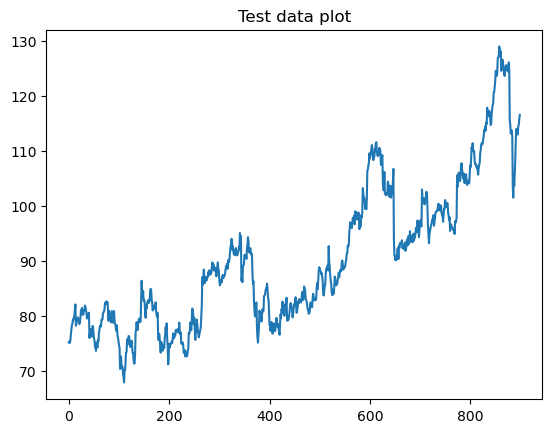

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.0604685695711957
Normalized Benchmark: 0.04681090117998735


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

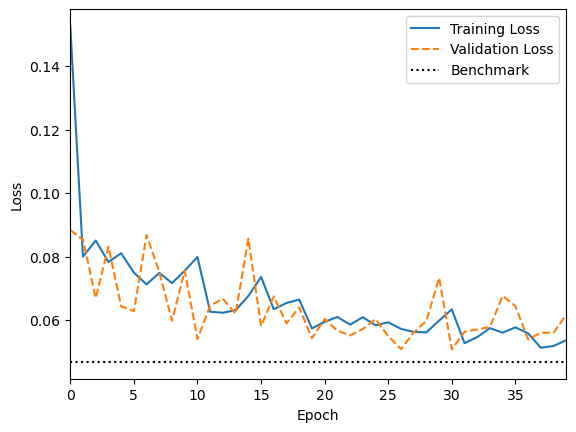

variance of returns for old data:  0.0013242818823962466
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(75.1527)
period from idx:  0  to idx  5
prediction at 5:  tensor(73.4942)
last price from test data:  75.15274810791016
real price 5 steps forward:  tensor(77.5386)
kelly weight:  {tensor(-16.6644)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(76.6974)
period from idx:  5  to idx  10
prediction at 5:  tensor(74.8404)
last price from test data:  tensor(76.6974)
real price 5 steps forward:  tensor(79.6797)
kelly weight:  {tensor(-18.2830)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(79.2209)
period from idx:  10  to idx  15
prediction at 5:  tensor(74.1336)
last price from test data:  tensor(79.2209)
real price 5 steps forward:  tensor(78.6091)
kelly weight:  {tensor(-30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(78.18

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(74.6926)
period from idx:  125  to idx  130
prediction at 5:  tensor(73.4344)
last price from test data:  tensor(74.6926)
real price 5 steps forward:  tensor(71.3212)
kelly weight:  {tensor(-12.7198)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(72.0292)
period from idx:  130  to idx  135
prediction at 5:  tensor(72.7067)
last price from test data:  tensor(72.0292)
real price 5 steps forward:  tensor(78.8393)
kelly weight:  {tensor(7.1027)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(77.6594)
period from idx:  135  to idx  140
prediction at 5:  tensor(79.2363)
last price from test data:  tensor(77.6594)
real price 5 steps forward:  tensor(79.5136)
kelly weight:  {tensor(15.3331)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(79.2271)
period from idx:  140  to idx  145
prediction at 5:  tensor(78.7921)
last price from test data:  tensor(79.2271)
real price 5

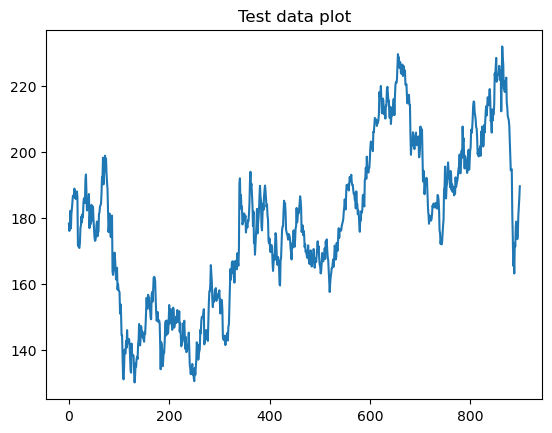

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 2.6166071763565375
Normalized Benchmark: 0.05565234359056786


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

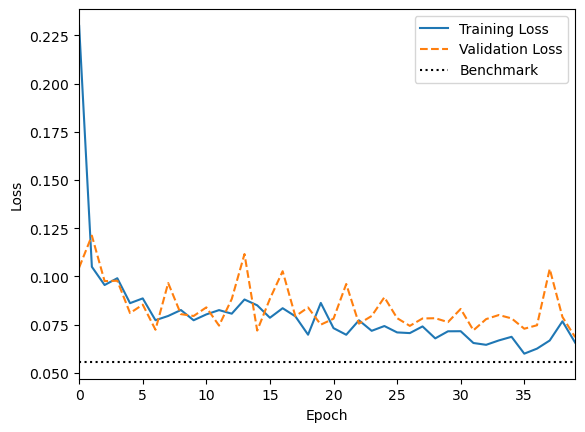

variance of returns for old data:  0.0018833270558730425
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(177.3412)
period from idx:  0  to idx  5
prediction at 5:  tensor(178.6942)
last price from test data:  177.34120178222656
real price 5 steps forward:  tensor(181.2936)
kelly weight:  {tensor(4.0511)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(176.9116)
period from idx:  5  to idx  10
prediction at 5:  tensor(180.1003)
last price from test data:  tensor(176.9116)
real price 5 steps forward:  tensor(186.7925)
kelly weight:  {tensor(9.5706)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(186.5348)
period from idx:  10  to idx  15
prediction at 5:  tensor(190.6089)
last price from test data:  tensor(186.5348)
real price 5 steps forward:  tensor(186.0192)
kelly weight:  {tensor(11.5973)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  t

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(131.2016)
period from idx:  110  to idx  115
prediction at 5:  tensor(147.3211)
last price from test data:  tensor(131.2016)
real price 5 steps forward:  tensor(140.7818)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(142.8868)
period from idx:  115  to idx  120
prediction at 5:  tensor(150.8233)
last price from test data:  tensor(142.8868)
real price 5 steps forward:  tensor(143.4023)
kelly weight:  {tensor(29.4923)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(143.2735)
period from idx:  120  to idx  125
prediction at 5:  tensor(146.7918)
last price from test data:  tensor(143.2735)
real price 5 steps forward:  tensor(142.0259)
kelly weight:  {tensor(13.0390)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(133.2223)
period from idx:  125  to idx  130
prediction at 5:  tensor(139.4915)
last price from test data:  tensor(133.2223)
r

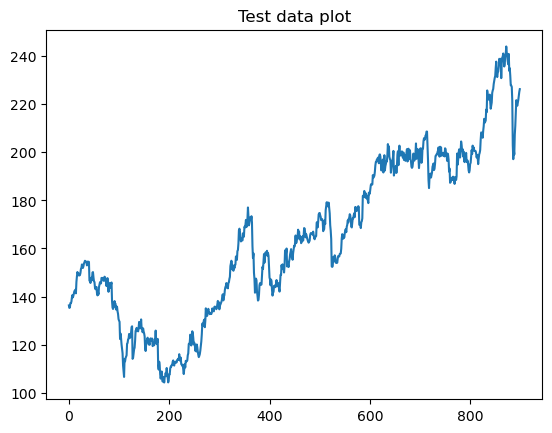

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.7675684558790783
Normalized Benchmark: 0.04813002914866846


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

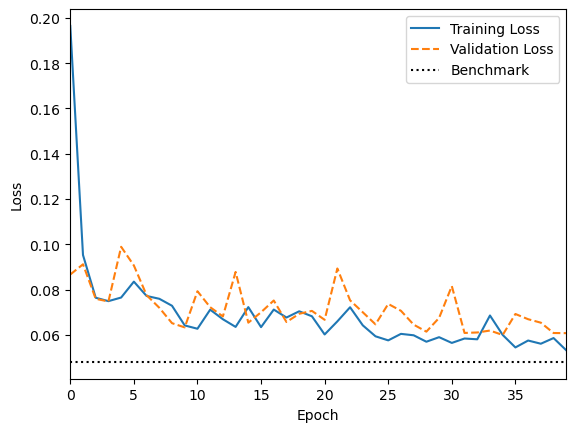

variance of returns for old data:  0.0021931423811328184
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.3259)
period from idx:  0  to idx  5
prediction at 5:  tensor(136.0393)
last price from test data:  135.32594299316406
real price 5 steps forward:  tensor(137.8320)
kelly weight:  {tensor(2.4036)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(137.2324)
period from idx:  5  to idx  10
prediction at 5:  tensor(135.6152)
last price from test data:  tensor(137.2324)
real price 5 steps forward:  tensor(141.3989)
kelly weight:  {tensor(-5.3733)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(140.3534)
period from idx:  10  to idx  15
prediction at 5:  tensor(138.7526)
last price from test data:  tensor(140.3534)
real price 5 steps forward:  tensor(146.0419)
kelly weight:  {tensor(-5.2004)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.6164)
period from idx:  105  to idx  110
prediction at 5:  tensor(125.1561)
last price from test data:  tensor(122.6164)
real price 5 steps forward:  tensor(106.5306)
kelly weight:  {tensor(9.4443)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(108.6391)
period from idx:  110  to idx  115
prediction at 5:  tensor(118.4548)
last price from test data:  tensor(108.6391)
real price 5 steps forward:  tensor(115.5079)
kelly weight:  {tensor(30.)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(115.0128)
period from idx:  115  to idx  120
prediction at 5:  tensor(119.0253)
last price from test data:  tensor(115.0128)
real price 5 steps forward:  tensor(124.3895)
kelly weight:  {tensor(15.9078)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.5046)
period from idx:  120  to idx  125
prediction at 5:  tensor(125.3331)
last price from test data:  tensor(122.5046)
re

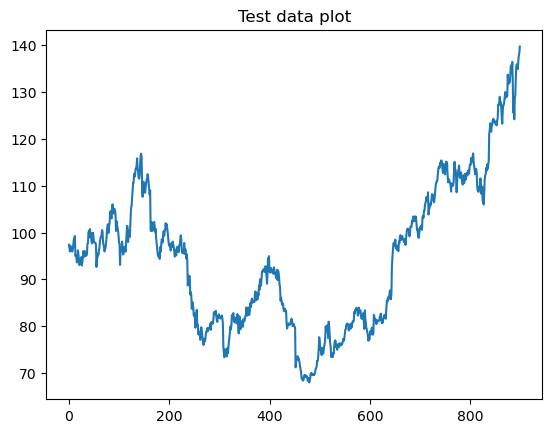

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.389926178510799
Normalized Benchmark: 0.07114975974076199


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

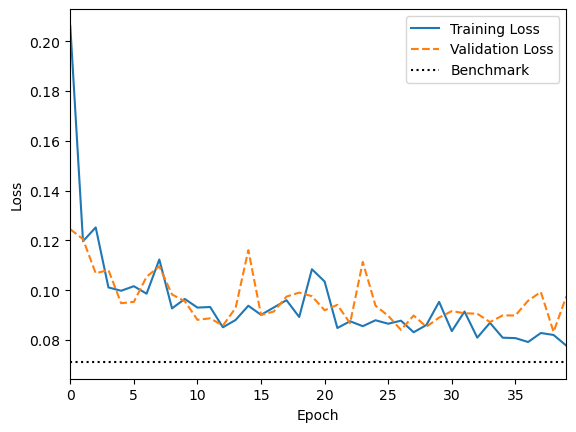

variance of returns for old data:  0.0022217870347951293
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.9744)
period from idx:  0  to idx  5
prediction at 5:  tensor(100.7878)
last price from test data:  95.974365234375
real price 5 steps forward:  tensor(96.4146)
kelly weight:  {tensor(22.5736)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(96.4146)
period from idx:  5  to idx  10
prediction at 5:  tensor(100.2814)
last price from test data:  tensor(96.4146)
real price 5 steps forward:  tensor(98.6032)
kelly weight:  {tensor(18.0512)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.6433)
period from idx:  10  to idx  15
prediction at 5:  tensor(101.7687)
last price from test data:  tensor(97.6433)
real price 5 steps forward:  tensor(94.5716)
kelly weight:  {tensor(19.0159)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(96.5682)
period from idx:  105  to idx  110
prediction at 5:  tensor(102.3061)
last price from test data:  tensor(96.5682)
real price 5 steps forward:  tensor(96.7218)
kelly weight:  {tensor(26.7434)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.4547)
period from idx:  110  to idx  115
prediction at 5:  tensor(101.3162)
last price from test data:  tensor(95.4547)
real price 5 steps forward:  tensor(99.7935)
kelly weight:  {tensor(27.6384)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.7585)
period from idx:  115  to idx  120
prediction at 5:  tensor(102.0328)
last price from test data:  tensor(97.7585)
real price 5 steps forward:  tensor(99.4096)
kelly weight:  {tensor(19.6791)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.3695)
period from idx:  120  to idx  125
prediction at 5:  tensor(103.7312)
last price from test data:  tensor(100.3695)
real p

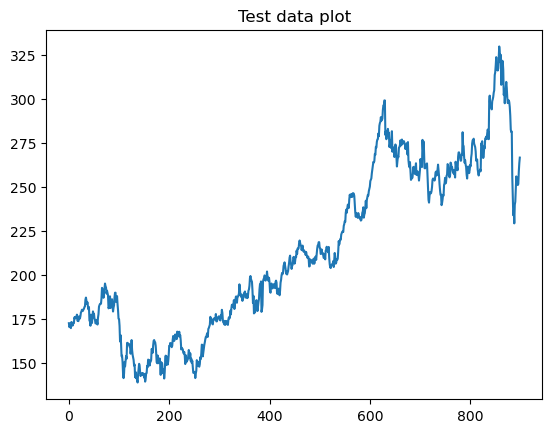

in sequences shape:  (1091, 50, 11)
targets shape:  (1091, 1)
train loader length:  28
val loader length:  7
Benchmark Celsius: 1.860277812494788
Normalized Benchmark: 0.04750223048899943


INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 1.4 M  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.641     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

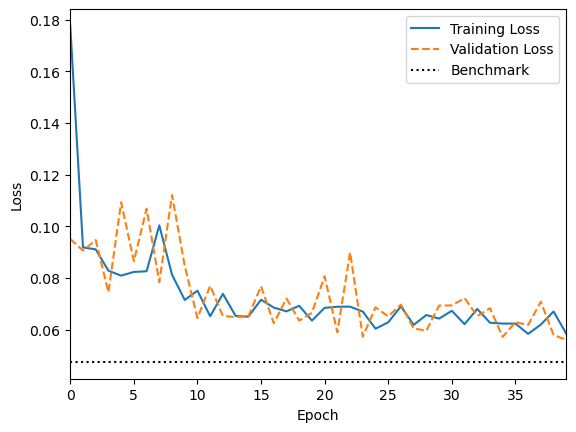

variance of returns for old data:  0.002141476405310776
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(170.9581)
period from idx:  0  to idx  5
prediction at 5:  tensor(171.8265)
last price from test data:  170.9580535888672
real price 5 steps forward:  tensor(173.3057)
kelly weight:  {tensor(2.3722)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(169.8192)
period from idx:  5  to idx  10
prediction at 5:  tensor(168.9191)
last price from test data:  tensor(169.8192)
real price 5 steps forward:  tensor(172.7976)
kelly weight:  {tensor(-2.4753)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.0779)
period from idx:  10  to idx  15
prediction at 5:  tensor(172.5011)
last price from test data:  tensor(173.0779)
real price 5 steps forward:  tensor(175.5920)
kelly weight:  {tensor(-1.5562)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  te

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(160.8666)
period from idx:  120  to idx  125
prediction at 5:  tensor(165.7227)
last price from test data:  tensor(160.8666)
real price 5 steps forward:  tensor(163.0216)
kelly weight:  {tensor(14.0963)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(157.5028)
period from idx:  125  to idx  130
prediction at 5:  tensor(160.0784)
last price from test data:  tensor(157.5028)
real price 5 steps forward:  tensor(148.4801)
kelly weight:  {tensor(7.6360)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(151.7388)
period from idx:  130  to idx  135
prediction at 5:  tensor(156.5864)
last price from test data:  tensor(151.7388)
real price 5 steps forward:  tensor(141.8039)
kelly weight:  {tensor(14.9180)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(141.4214)
period from idx:  135  to idx  140
prediction at 5:  tensor(144.8834)
last price from test data:  tensor(141.4214

In [33]:
from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'SAAB-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 40
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)

    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=176, num_hidden_layers=7, out_dim=1, dropout=0.1, num_heads=22)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_gru_v1
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=30,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)
    

    #plot_realized_returns(pnl, plot_only_cumulative=True)

In [27]:
import numpy as np
print(np.array(all_weights).shape)

(22, 90)


[[-0.00403612 -0.01349724 -0.00275923 ...  0.01969317  0.01340927
   0.        ]
 [ 0.04444999  0.02715529  0.01262242 ...  0.066       0.066
   0.        ]
 [ 0.02339912  0.01603584 -0.00602344 ...  0.066       0.066
   0.        ]
 ...
 [ 0.00528793 -0.01182126 -0.01144094 ... -0.01121963 -0.00298956
   0.        ]
 [ 0.04966196  0.03971273  0.04183505 ...  0.00503613  0.01978325
   0.        ]
 [ 0.00521884 -0.00544566 -0.00342366 ...  0.066       0.066
   0.        ]]
[[ 0.          0.          0.         ...  8.95144176  6.09512472
   0.        ]
 [20.20454025 12.34331322  5.73746347 ... 30.         30.
   0.        ]
 [10.63596439  7.28901911  0.         ... 30.         30.
   0.        ]
 ...
 [ 2.40360498  0.          0.         ...  0.          0.
   0.        ]
 [22.57361794 18.05124283 19.01593018 ...  2.28914928  8.99238491
   0.        ]
 [ 2.37220144  0.          0.         ... 30.         30.
   0.        ]]
(22, 900)
(900,)
900


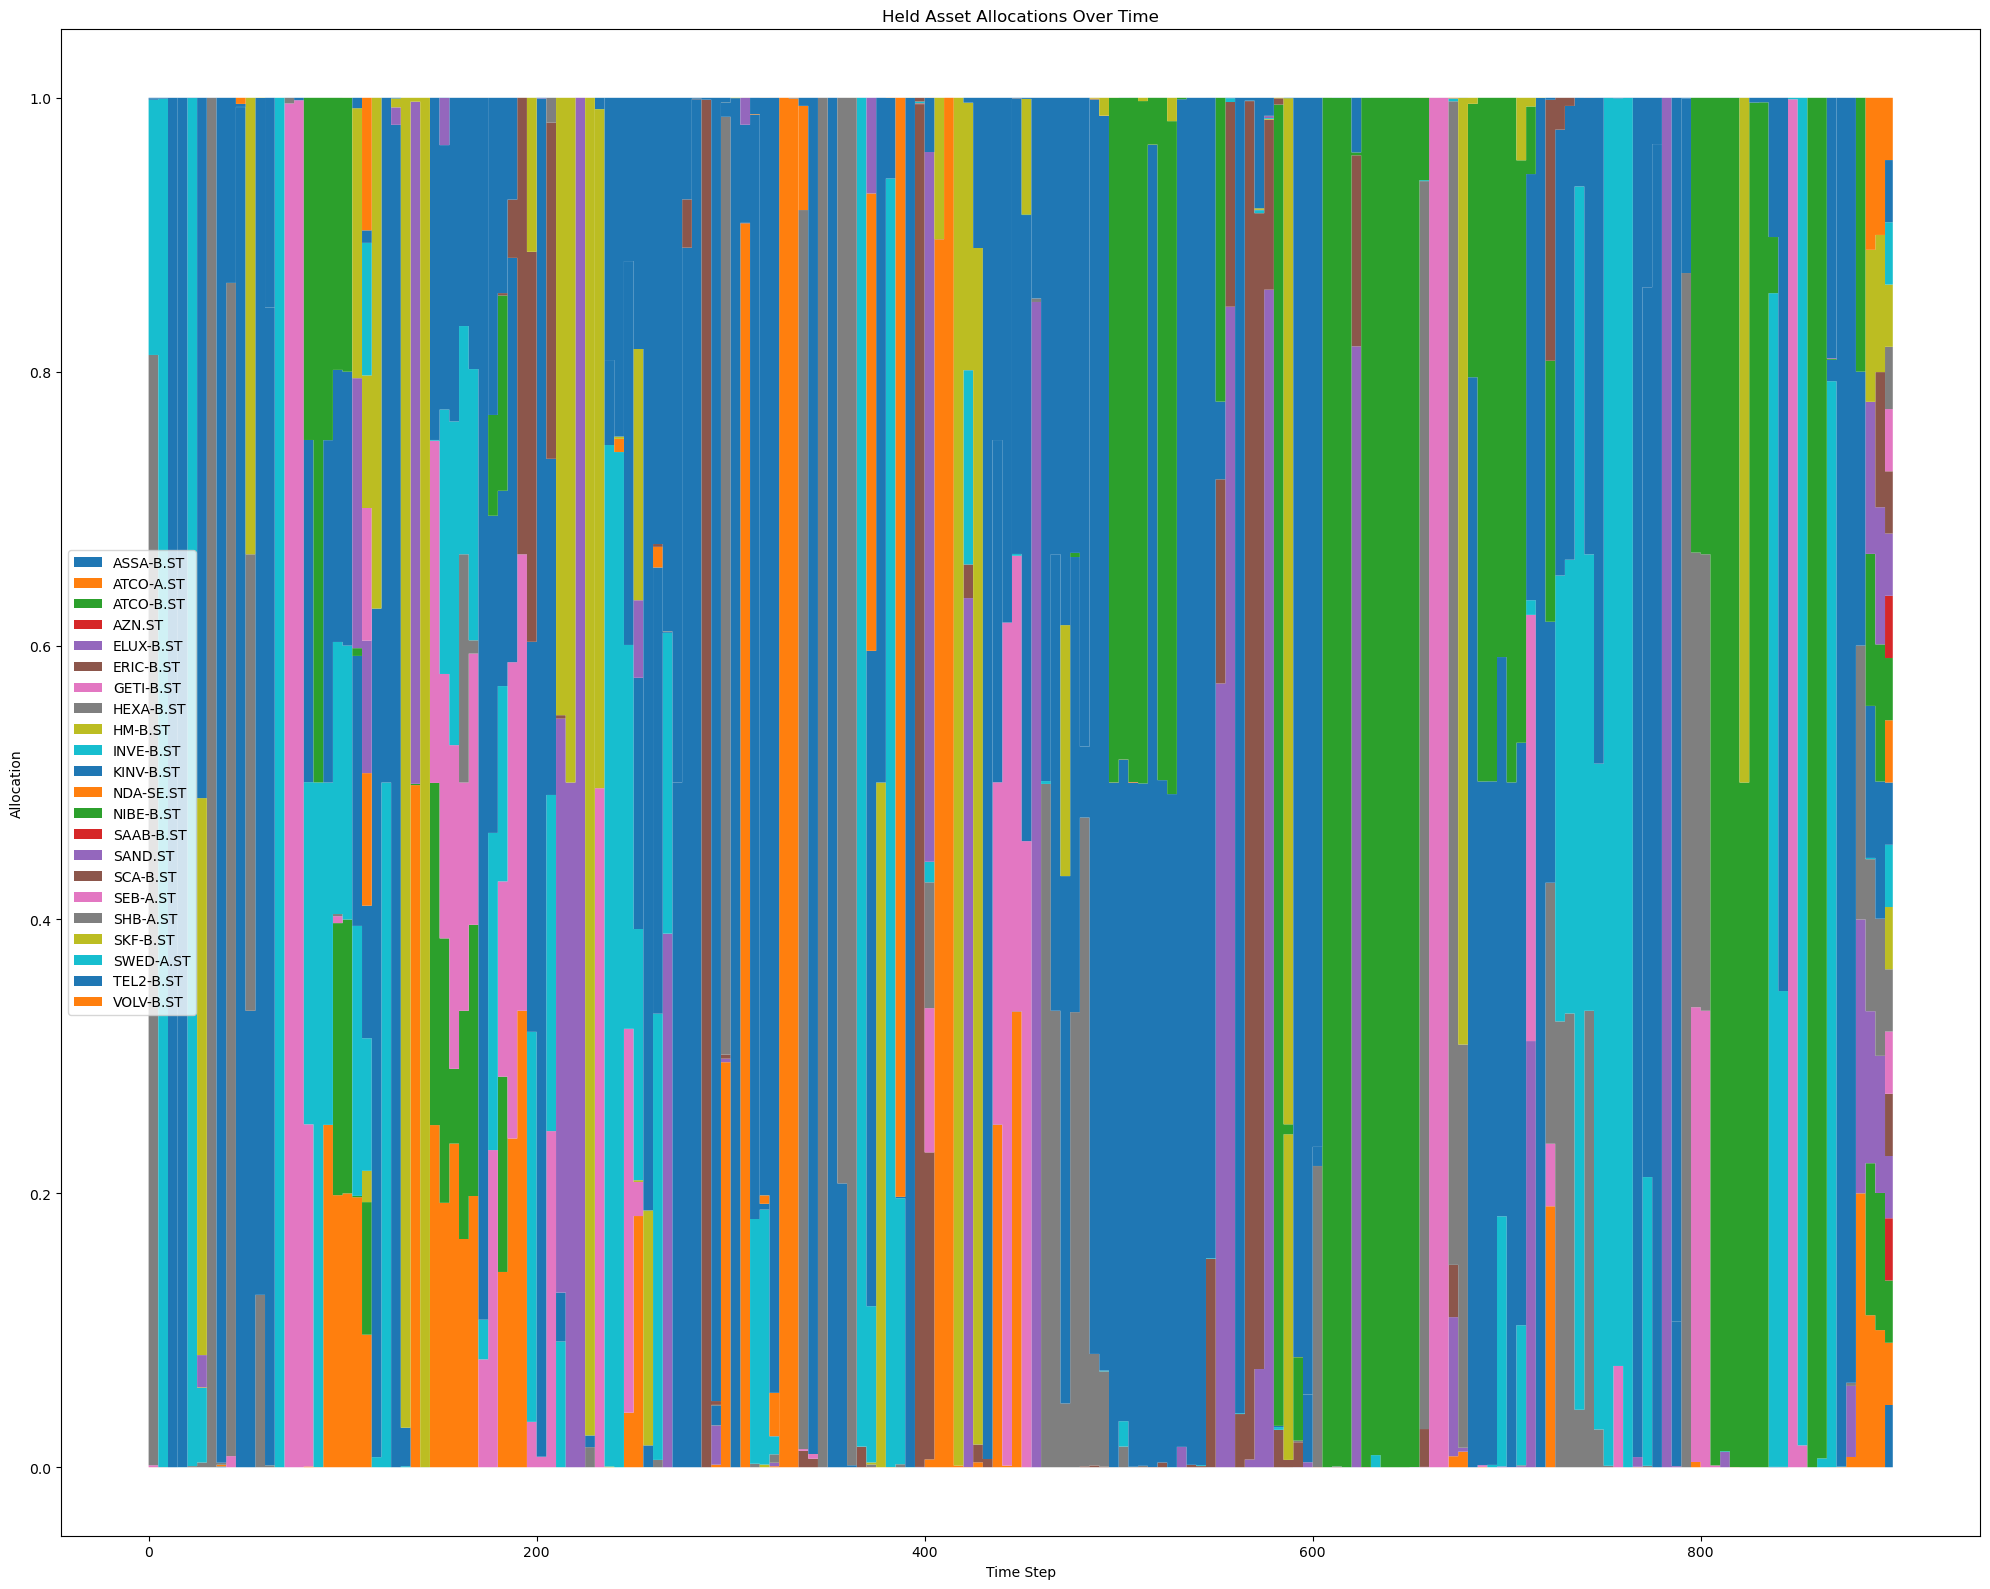

In [34]:
lowball_variance = 0.0022
trading_cost = 0.005

lowball_returns = all_weights*np.array([lowball_variance])
print(lowball_returns)

trading_cost_adjusted_returns = np.where(lowball_returns < trading_cost, lowball_returns - lowball_returns, lowball_returns)
trading_cost_adjusted_weights = trading_cost_adjusted_returns / lowball_variance
print(trading_cost_adjusted_weights)


from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations
import matplotlib.pyplot as plt

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_allocations(alloc, tickers)

(22, 900)
(22, 900)
[[0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 ...
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]]
(900,)
[-3.25169371e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -4.06422422e-03  3.80591637e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -4.99722233e-03  2.19823027e-03  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -4.99950802e-03  1.61507753e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -4.99879221e-03
  2.33711919e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -4.72144028e-03  2.50432073e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -4.98269298e-03  2.05119649e-02  0.00000000e+00
  0.00000

Text(0, 0.5, 'Returns')

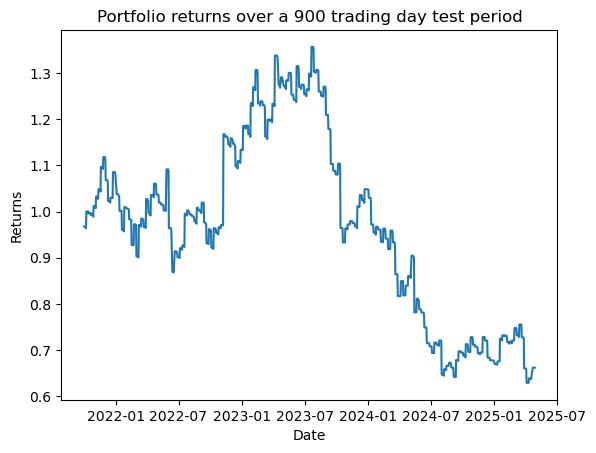

In [35]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt
returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)
test_alloc = np.ones((22,900))/22
print(test_alloc)
portfolio_returns = calculate_portfolio_returns(alloc, returns)
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print(portfolio_cum_return)

test_indices = df.index[-900*22::22]
plt.plot(test_indices, portfolio_cum_return, label='portfolio returns')
plt.title('Portfolio returns over a 900 trading day test period')
plt.xlabel('Date')
plt.ylabel('Returns')


DatetimeIndex(['2021-09-30', '2021-10-01', '2021-10-04', '2021-10-05',
               '2021-10-06', '2021-10-07', '2021-10-08', '2021-10-11',
               '2021-10-12', '2021-10-13',
               ...
               '2025-04-11', '2025-04-14', '2025-04-15', '2025-04-16',
               '2025-04-17', '2025-04-22', '2025-04-23', '2025-04-24',
               '2025-04-25', '2025-04-28'],
              dtype='datetime64[ns]', name='Date', length=900, freq=None)
900
[11.39686355 11.31727194 11.25258812 11.36665288 11.23263317 11.40652557
 11.34813842 11.35384295 11.38108738 11.45051825 11.49800513 11.56505374
 11.53769329 11.57945076 11.59120165 11.63124022 11.77759597 11.70838981
 11.75319871 11.658384   11.68941887 11.644011   11.68435121 11.81727048
 11.8812165  11.94160694 11.93147759 11.97607684 11.92679618 11.99107053
 12.04764797 11.94289721 12.05022273 11.97096225 12.02610682 11.87906998
 11.92520939 11.91413458 11.8213404  11.8605612  11.94295874 11.56286478
 11.67372922 11.53715

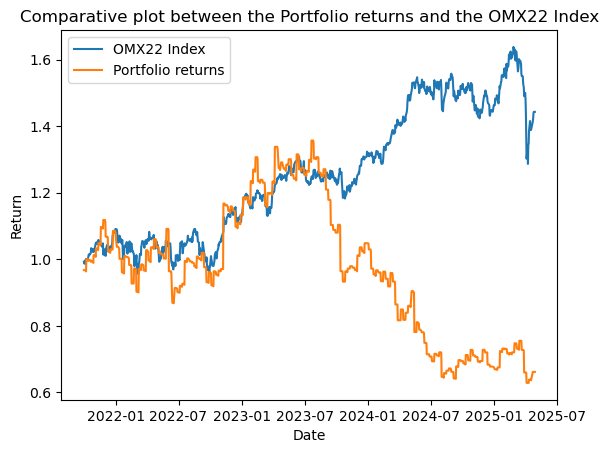

In [36]:

df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


print(test_indices)

index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values
print(len(index_test_values))
print(index_test_values)
index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()